In [1]:
from preamble import *
numpyro.set_host_device_count(4)
numpyro.set_platform("cpu")
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=4"

2025-08-17 21:47:37,741 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch


In [2]:
def lnlike_OOTspec(parameters,
                   plot=False,
                   savefigs=False,
                   samples=None,
                  ):

    ln_like = 0.0
    params = {name: value for name, value in zip(params_config.keys(), parameters)}

    # For each visit, we need to extract spectra the appropriate wavelengths and calculate the log likelihood
    Cool_occulted, Cool_unocculted, Phot = [
        get_BTSettl_spectrum(T=Temp)
        for Temp in [params.get('T_occulted', default_params['T_occulted']),
                     params.get('T_unocculted', default_params['T_unocculted']),
                     params.get('T_phot', default_params['T_phot'])] ]
    
    'Calculate combined spectrum'
    f_occulted = params['f_cool_occulted']
    f_unocculted = params['f_cool_unocculted']
    f_phot = 1.0 - (f_occulted + f_unocculted)
    _f = (f_occulted*Cool_occulted.flux.value + f_unocculted*Cool_unocculted.flux.value + f_phot*Phot.flux.value)
    _model_flux = (_f/np.nanmean(_f))
    
    convolved = convolve_spectrum(panchromatic_wavelengths, _model_flux, sigma=filter_sigma)
    binned_model_flux = bintogrid(panchromatic_wavelengths, convolved, newx=SED_wavelengths)['y'] 
    model_flux = (binned_model_flux/np.nanmean(binned_model_flux))

    'Calculate ln_like for the light curve model'
    chisq = np.nansum(((calibrated_mean_spec - model_flux) ** 2) / ((oot_spec_err) ** 2))
    OOT_err_weight = np.nansum(1.0 / np.sqrt(2.0 * np.pi * (oot_spec_err)**2))
    ln_like += (OOT_err_weight - 0.5 * chisq)
    
    dof = np.sum(~np.isnan(SED_wavelengths)) - 5
    reduced_chisq = chisq/dof
    
    if plot:
        fig, [ax0,ax1] = plt.subplots(2,1,sharex=True, figsize=(5,4),gridspec_kw={'height_ratios': [3, 1]})
        ax0.errorbar(SED_wavelengths, calibrated_mean_spec, yerr = (oot_spec_err),fmt='o',ms=3,alpha=0.6)
        ax0.plot(SED_wavelengths, model_flux,color='r',alpha=0.7,zorder=100)
        ax0.set_ylabel('Relative Flux')
        ax1.set_ylabel(r'Residuals ($\sigma$)')
        ax1.set_xlabel(r'Wavelength ($\mu$m)')

        # ax1.set_title('Residuals (sigma)')
        ax1.scatter(SED_wavelengths, (calibrated_mean_spec - model_flux)/(oot_spec_err), s=3,alpha=0.6,edgecolors='black')
        if savefigs:
            plt.savefig(f'../figs/{visit}_{model_designation}_{n_steps}steps_OOTSpec.png',dpi=250)
        plt.show()
        plt.clf()
        
        print(f'This Models Reduced Chisq = {reduced_chisq:.3f} for {5} parameters and {np.sum(~np.isnan(SED_wavelengths))} data points')

    return ln_like

In [8]:
def lnlike_specLC(parameters, plot=False, savefigs=False, samples=None):

    ln_like = 0.0
    params = {name: value for name, value in zip(params_config.keys(), parameters)}

    # Call the spectra based on temp
    Cool_occulted, Cool_unocculted, Phot = [
        get_BTSettl_spectrum(T=Temp, grid = speclc_grid, w = speclc_bin_edges)
        for Temp in [params.get('T_occulted', default_params['T_occulted']),
                     params.get('T_unocculted', default_params['T_unocculted']),
                     params.get('T_phot', default_params['T_phot'])] ]
    
    # Calculate systematics model
    ramp = ramp_model(phase=ramp_phase,
                    r1=params.get('r1', default_params['r1']),
                    r2=params.get('r2', default_params['r2']),
                    r3=params.get('r3', default_params['r3']))
    breathing = breathing_model(phase=breathing_phase,
                              b1=params.get('b1', default_params['b1']),
                              b2=params.get('b2', default_params['b2']),
                              b3=params.get('b3', default_params['b3']),
                              b4=params.get('b4', default_params['b4']))
    systematics = (breathing * ramp)

    'Update Planet Parameters'
    planet_parameters['u1'] = np.array([params[f"u1_w{j}"] for j in range(1,len(speclc_bin_edges))])
    planet_parameters['u2'] = np.array([params[f"u2_w{j}"] for j in range(1,len(speclc_bin_edges))])
    planet_parameters['rp'] = np.array([params[f"rp_rs_w{j}"] for j in range(1,len(speclc_bin_edges))])
    planet_parameters['t0'] = params.get('t0', default_params['t0'])
    planet_parameters['ecc'] = 0.0
    planet_parameters['a'] = params.get('a_rstar', default_params['a_rstar'])

    'Update stellar parameters'
    # First, set all spot parameters to the unocculted values
    active_star.phot = Phot.flux.value
    active_star.wavelength = Phot.wavelength.to_value(u.m)
    active_star.spectrum = jnp.array([Cool_unocculted.flux.value] * n_spots)
    active_star.temperature = jnp.array([params.get("T_unocculted", default_params["T_unocculted"])] * n_spots) 
    active_star.rad = jnp.array([10**(jnp.array(params['log_fixedspot_radii']))] * n_spots)
    active_star.times = time_from_T0
    active_star.T_eff = params.get('T_phot',default_params['T_phot'])
    active_star.lon = active_star.lon.at[0].set(params.get(f"spot1_lon", default_params[f"spot1_lon"]) )
    active_star.lat = active_star.lat.at[0].set(params.get(f"spot1_lat", default_params[f"spot1_lat"]) )
    active_star.rad = active_star.rad.at[0].set(params.get(f"spot1_rad", default_params[f"spot1_rad"]) )
    # Now replace the 1st spot with the occulted spot values
    active_star.spectrum = active_star.spectrum.at[1].set(Cool_occulted.flux.value)
    active_star.temperature = active_star.temperature.at[1].set(params.get("T_occulted", default_params["T_occulted"]))
    active_star.lon = active_star.lon.at[1].set(params.get(f"spot2_lon", default_params[f"spot2_lon"]) )
    active_star.lat = active_star.lat.at[1].set(params.get(f"spot2_lat", default_params[f"spot2_lat"]) )
    active_star.rad = active_star.rad.at[1].set(params.get(f"spot2_rad", default_params[f"spot2_rad"]) )
    active_star.spectrum = active_star.spectrum.at[2].set(Cool_occulted.flux.value)
    active_star.temperature = active_star.temperature.at[2].set(params.get("T_occulted", default_params["T_occulted"]))
    active_star.lon = active_star.lon.at[2].set(params.get(f"spot3_lon", default_params[f"spot3_lon"]) )
    active_star.lat = active_star.lat.at[2].set(params.get(f"spot3_lat", default_params[f"spot3_lat"]) )
    active_star.rad = active_star.rad.at[2].set(params.get(f"spot3_rad", default_params[f"spot3_rad"]) )
    
    lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)        
    
    for i, lc_i in enumerate(lc.T):
        lc_i /= np.nanmean(lc_i)
        model_i = systematics * lc_i
        model_i /= np.nanmean(model_i)
        normalized_flux = data_flux[i, :]/np.nanmean(data_flux[i, :])
        chisq = np.nansum(((normalized_flux - model_i) ** 2) / (relative_err[i, :] ** 2))
        err_weight = np.nansum(1.0 / np.sqrt(2.0 * np.pi * (relative_err[i, :])**2))
        ln_like += (err_weight - 0.5 * chisq)
        
    if plot:
        'Plot the stellar surface'
        active_star.plot_star(
            t0=planet_parameters['t0'],
            rp=np.nanmean(planet_parameters['rp']),  # Exoplanet radius in units of stellar radii
            a=planet_parameters['a'],  # Planetary semi-major axis in units of stellar radii
            inclination=planet_parameters['inclination'],  # Planetary orbital inclination [radians]
            ecc=0.0 )
        plt.title(f'{visit} Stellar Background at T0')
        if savefigs:
            plt.savefig(f'../figs/{visit}_{model_designation}_{n_steps}steps_starmap.png', dpi=250)
        plt.show()
        plt.clf()
        
        'Plot the systematics models'
        fig, axs = plt.subplots(4,1, figsize=(6,6))
        plt.title('Systematics')
        axs[0].set_title('Ramp')
        axs[1].set_title('Breathing')
        axs[2].set_title('Breathing')
        axs[3].set_title('Ramp x Breathing')
        axs[0].scatter(ramp_phase, ramp,color='k',alpha=0.8,s=2)
        axs[1].scatter(breathing_phase, breathing,color='k',alpha=0.8,s=2)
        axs[2].scatter(ramp_phase, breathing,color='k',alpha=0.8,s=2)
        axs[3].scatter(img_date, ramp*breathing,color='k',alpha=0.8,s=2)
        axs[0].set_xlabel('Ramp Phase')
        axs[1].set_xlabel('HST Orbital Phase')
        axs[2].set_xlabel('Ramp Phase')
        axs[3].set_xlabel('Time (BJD)')
        if savefigs:
            plt.savefig(f'../figs/{visit}_{model_designation}_{n_steps}steps_systematics_models.png',dpi=250)
        plt.show()
        plt.clf()
        'Plot the transmission and contamination spectra'
        'First Remove nan data'
        mask = ~np.isnan(time_from_T0)
        nonnan_time_from_T0 = time_from_T0[mask]
        active_star.times = nonnan_time_from_T0
        _, nanremoved_contam, _, _, nanremoved_spectrum_at_transit = active_star.transit_model(**planet_parameters)
        fig, axs = plt.subplots(3,1,figsize=(5,5))
        axs[0].set_title('Contaminated Transmission Spectrum')
        axs[0].scatter(data_wavelengths, nanremoved_contam * 1e6 ,s=2,color='k')
        axs[1].set_title('Stellar Contamination')
        axs[1].scatter(data_wavelengths, (nanremoved_contam-planet_parameters['rp']**2)*1e6,s=2,color='k')
        axs[2].set_title('De-contaminated Transmission Spectrum')
        axs[2].scatter(data_wavelengths, (planet_parameters['rp'])**2 * 1e6,s=2,color='k')
        axs[0].set_ylabel('Transit Depth (ppm)')
        axs[1].set_ylabel('Transit Depth (ppm)')
        axs[2].set_ylabel('Transit Depth (ppm)')
        plt.xlabel(r'Wavelength ($\mu$m)')
        if savefigs:
            plt.savefig(f'../figs/{visit}_{model_designation}_{n_steps}steps_{len(speclc_bin_edges)-1}bins_transmission.png',dpi=250)
        plt.show()
        plt.clf()

        'Re-set to the original array (containing nans)'
        active_star.times = time_from_T0
        
        'Set up the data + model plots'
        fig, axes = plt.subplots(4, 1, figsize=(8,12))
        axes[0].set_title(f"{visit}")
        axes[0].set_xlabel("Time from midtransit")
        axes[0].set_ylabel("Relative Flux")
        axes[1].set_title("Systematic-corrected")
        axes[1].set_xlabel("Time from midtransit")
        axes[2].set_title("Residuals")
        axes[2].set_xlabel("Time from midtransit")
        axes[2].set_ylabel(r"$\sigma$")
        axes[3].set_title("Residuals")
        axes[3].set_xlabel("HST Phase")
        axes[3].set_ylabel(r"$\sigma$")
        
        chisq_per_wavelength = []
        for i, lc_i in enumerate(lc.T):
            lc_i /= np.nanmean(lc_i)
            model_i = systematics * lc_i
            model_i /= np.nanmean(model_i)
            normalized_flux = data_flux[i, :]/np.nanmean(data_flux[i, :])
            chisq = np.nansum(((normalized_flux - model_i) ** 2) / (relative_err[i, :] ** 2))
            chisq_per_wavelength.append(chisq)
        
            # First plot (data + model)
            axes[0].errorbar(
                time_from_T0,
                normalized_flux - (0.0022*i),
                yerr=relative_err[i, :],
                # markeredgecolor='gray',
                alpha=0.7,fmt='o',ms=2.5,
                color=plt.cm.inferno((data_wavelengths[i] - data_wavelengths.min()) / np.ptp(data_wavelengths)))
            # Second plot (data & model)/systematics
            axes[1].errorbar(
                time_from_T0,
                (normalized_flux/systematics)/np.nanmean(normalized_flux/systematics) - (0.0022*i),
                yerr=relative_err[i, :],
                # markeredgecolor='gray',
                alpha=0.7,fmt='o',ms=2.5,
                color=plt.cm.inferno((data_wavelengths[i] - data_wavelengths.min()) / np.ptp(data_wavelengths)))
            # third plot residuals
            axes[2].scatter(
                time_from_T0,
                (normalized_flux-model_i)/relative_err[i, :]- (3.5*i),
                s=5,
                # edgecolors='black',
                alpha=0.7,
                color=plt.cm.inferno((data_wavelengths[i] - data_wavelengths.min()) / np.ptp(data_wavelengths)))
            axes[2].axhline((0 - 3.5 * i),color='k',zorder=-100,alpha=0.5)
            # fourth plot residuals in HST phase
            axes[3].scatter(
                breathing_phase,
                (normalized_flux-model_i)/relative_err[i, :],
                s=5,
                # edgecolors='black',
                alpha=0.7,
                color=plt.cm.inferno((data_wavelengths[i] - data_wavelengths.min()) / np.ptp(data_wavelengths)))
            axes[3].axhline(0,color='k',zorder=-100,alpha=0.5)

            # Plot the models
            axes[0].plot(
                time_from_T0,
                model_i - (0.0022*i),
                color='k',zorder=100,alpha=0.7)
            axes[1].plot(
                time_from_T0,
                lc_i - (0.0022*i),
                color='k',zorder=100,alpha=0.7)
        if savefigs:
            plt.savefig(f'../figs/{visit}_{model_designation}_{n_steps}steps_{len(speclc_bin_edges)-1}bins_specLC.png',dpi=250)
        plt.show()
        plt.clf()

        'Set up the data + model plots'
        fig, axes = plt.subplots(4, 1, figsize=(6, 12))
        axes[0].set_title(f"{visit}")
        axes[0].set_xlabel("Time from midtransit")
        axes[0].set_ylabel("Relative Flux")
        # axes[0].set_xlim(-0.085,0.085)
        axes[1].set_title("De-Trended")
        axes[1].set_xlabel("Time from midtransit")
        # axes[1].set_xlim(-0.085,0.085)
        axes[2].set_title("Residuals")
        axes[2].set_xlabel("Time from midtransit")
        axes[2].set_ylabel(r"$\sigma$")
        # axes[2].set_xlim(-0.085,0.085)
        axes[3].set_title("Residuals")
        axes[3].set_xlabel("HST Phase")
        axes[3].set_ylabel(r"$\sigma$")
        axes[0].set_xlim(-0.086,0.086)
        axes[1].set_xlim(-0.086,0.086)
        axes[2].set_xlim(-0.086,0.086)
        axes[3].set_xlim(np.nanmin(breathing_phase),np.nanmax(breathing_phase))
        for i, lc_i in enumerate(lc.T):
            lc_i /= np.nanmean(lc_i)
            model_i = systematics * lc_i
            model_i /= np.nanmean(model_i)

            normalized_flux = data_flux[i, :]/np.nanmean(data_flux[i, :])
        
            # First plot (data + model)
            axes[0].errorbar(
                time_from_T0,
                normalized_flux - (0.0022*i),
                yerr=relative_err[i, :],
                # markeredgecolor='gray',
                alpha=0.7,fmt='o',ms=2.0,
                color=plt.cm.inferno((data_wavelengths[i] - data_wavelengths.min()) / np.ptp(data_wavelengths)))
            # Second plot (data & model)/systematics
            axes[1].errorbar(
                time_from_T0,
                (normalized_flux/systematics)/np.nanmean(normalized_flux/systematics) - (0.0022*i),
                yerr=relative_err[i, :],
                # markeredgecolor='gray',
                alpha=0.7,fmt='o',ms=2.0,
                color=plt.cm.inferno((data_wavelengths[i] - data_wavelengths.min()) / np.ptp(data_wavelengths)))
            # third plot residuals
            axes[2].scatter(
                time_from_T0,
                (normalized_flux-model_i)/relative_err[i, :]- (3.5*i),
                # edgecolors='black',
                alpha=0.7,s=3,
                color=plt.cm.inferno((data_wavelengths[i] - data_wavelengths.min()) / np.ptp(data_wavelengths)))
            axes[2].axhline((0 - 3.5 * i),color='k',zorder=-100,alpha=0.5)
            # fourth plot residuals in HST phase
            axes[3].scatter(
                breathing_phase,
                (normalized_flux-model_i)/relative_err[i, :],
                # edgecolors='black',
                alpha=0.7,s=3,
                color=plt.cm.inferno((data_wavelengths[i] - data_wavelengths.min()) / np.ptp(data_wavelengths)))
            axes[3].axhline(0,color='k',zorder=-100,alpha=0.5)

            # Plot the models
            axes[0].plot(
                time_from_T0,
                model_i - (0.0022*i),
                color='k',zorder=100,alpha=0.7)
            axes[1].plot(
                time_from_T0,
                lc_i - (0.0022*i),
                color='k',zorder=100,alpha=0.7)

        if savefigs:
            plt.savefig(f'../figs/{visit}_{model_designation}_{n_steps}steps_{len(speclc_bin_edges)-1}bins_zoomedspeclcs.png',dpi=250)
        plt.show()
        plt.clf()

        total_chisq = np.nansum(chisq_per_wavelength)
        nparam = (n_dim-2)
        dof = np.sum(~np.isnan(time_from_T0))*len(data_wavelengths) - nparam
        reduced_chisq = total_chisq/dof
        print(f'This Models Reduced Chisq = {reduced_chisq:.3f} for {nparam} parameters and {np.sum(~np.isnan(time_from_T0))*len(data_wavelengths)} data points')

    return ln_like

In [9]:
def lnprob(parameters, plot=False, savefigs=False, samples=None):
    """
    Log-probability function for MCMC.

    Parameters:
    - parameters: np.ndarray, current parameter values.
    - kwargs: dict, additional arguments required for model computation.

    Returns:
    - ln_like: float, log-likelihood of the current parameter set.
    """
    
    params = {name: value for name, value in zip(params_config.keys(), parameters)}

    ln_like = 0.0

    'Check if all priors are satisfied'
    if all(bounds[0] <= params[key] <= bounds[1] for key, bounds in priors.items()):

        
        ln_like += lnlike_specLC(parameters,
                                 plot = plot, savefigs = savefigs, samples = samples)

        ln_like += lnlike_OOTspec(parameters,
                                  plot=plot, savefigs=savefigs, samples=samples)

        if plot:
            print(f'Max Log Likelihood = {ln_like:.1f}')
        return ln_like

    else:
        return -np.inf

In [10]:
_params_config={
    # Ramp Model Parameters
    "r1": (12.0,19.0),
    "r2": (-8.0,-6.0),
    "r3": (-0.001,0.001),
    #Breathing params
    "b1":(-0.1,0.1),
    "b2":(-0.1,0.1),
    "b3":(-0.1,0.1),
    "b4":(-0.1,0.1),
    # Planetary Parameters
    "a_rstar": (18.3,18.6),
    "t0": (-0.001,0.001),
    # Stellar Parameters
    "f_cool_unocculted":(0.1,0.2),
    "f_cool_occulted":(0.1,0.2),
    "T_unocculted": (2900,3200),
    "T_occulted": (3200,3400),    
    "T_phot": (3900,4100),
    "log_fixedspot_radii":(-1.8,-1.5), #This is the size scale of spots at the active latitudes

    # This spot sets the rotation, it is characteristic of the 'unocculted' spots
    "spot1_lon": (-1.2, -0.9),
    "spot1_lat": (1.0, 1.4),
    "spot1_rad": (0.2, 0.4),

    # Spot occulted in S22
    "spot2_lon": (0.89, 0.92),
    "spot2_lat": (1.80, 1.84),
    "spot2_rad": (0.0, 0.15),

    # This spot is maybe occulted in S22
    "spot3_lon": (0.05,0.06),
    "spot3_lat": (1.5,1.54),
    "spot3_rad": (0.25,0.32),

}

_priors={
    # Ramp Model Parameters
    "r1": (10.0, 24.0),
    "r2": (-15, -2.0),
    "r3": (-0.001, 0.001),
    #Breathing params
    "b1": (-0.2, 0.2),
    "b2": (-0.2, 0.2),
    "b3": (-0.5, 0.5),
    "b4": (-0.5, 0.5),
    
    # Transit Parameters
    "a_rstar": (17.0, 21.0),
    "t0": (-0.001,0.001),
    
    # Stellar Parameters
    "f_cool_unocculted":(0.0,0.5),
    "f_cool_occulted":(0.0,0.5),
    "T_unocculted": (2900,3700),
    "T_occulted": (2900,3700),     
    "T_phot": (3700,4200),
    "log_fixedspot_radii": (-3,-1),

    # This spot sets the rotation, it is characteristic of the 'unocculted' spots
    "spot1_lon": (-1.35, -0.5),
    "spot1_lat": (0.8, 1.8),
    "spot1_rad": (0.0, 0.6),

    # Spot occulted in S22
    "spot2_lon": (0.89, 0.92),
    "spot2_lat": (1.80, 1.84),
    "spot2_rad": (0.0, 0.15),

    # This spot is also occulted in S22
    "spot3_lon": (0.04,0.08),
    "spot3_lat": (1.48,1.55),
    "spot3_rad": (0.22,0.4),

}

In [11]:
visit = 'S22'

'Visit-specific definitions'
orbits_to_exclude = np.array([0]) if visit=='F21' else np.array([0,2,7])
# speclc_err_factor = F21_speclc_err_factor if visit=='F21' else S22_speclc_err_factor
speclc_bin_edges = F21_speclc_bin_edges if visit=='F21' else S22_speclc_bin_edges
SED_err_factor = F21_SED_err_factor if visit=='F21' else S22_SED_err_factor
SED_bin_edges = F21_SED_bin_edges if visit=='F21' else S22_SED_bin_edges
speclc_grid = get_interp_stellar_spectrum(speclc_bin_edges)
SED_grid = get_interp_stellar_spectrum(SED_bin_edges)

In [12]:
'Inference Parameters - EDIT'
n_spots = 900
n_steps = 2000
n_walkers = 300
n_burnin = int(n_steps/2)
model_designation = '3T'
SED_err_kluge = 180.0
filter_sigma = 2.0 * u.pixel

🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

Median relative photon uncertainty at 0.8403 micron = 350ppm
Median relative photon uncertainty at 0.8636 micron = 209ppm
Median relative photon uncertainty at 0.8858 micron = 269ppm
Median relative photon uncertainty at 0.8968 micron = 282ppm
Median relative photon uncertainty at 0.9079 micron = 252ppm
Median relative photon uncertainty at 0.9226 micron = 222ppm
Median relative photon uncertainty at 0.9386 micron = 233ppm
Median relative photon uncertainty at 0.9521 micron = 218ppm
Median relative photon uncertainty at 0.9632 micron = 253ppm
Median relative photon uncertainty at 0.9743 micron = 225ppm
Median relative photon uncertainty at 0.9890 micron = 211ppm
Median relative photon uncertainty at 1.0038 micron = 247ppm
Median relative photon uncertainty at 1.0148 micron = 330ppm
Median relative photon uncertainty at 1.0271 micron = 200ppm
Median relative photon uncertainty at 1.0480 micron = 142ppm
Median relative photon uncertainty at 1.0787 micron = 148ppm
Median relative photon u

  0%|          | 0/130 [00:00<?, ?it/s]

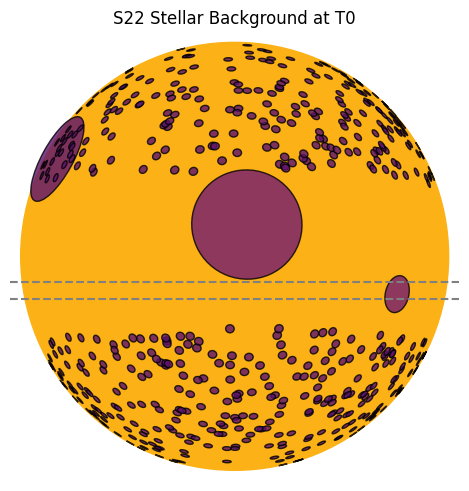

<Figure size 640x480 with 0 Axes>

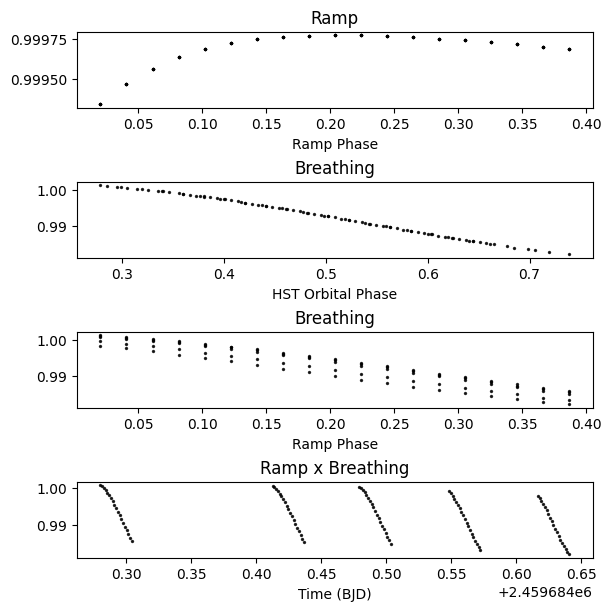

<Figure size 640x480 with 0 Axes>

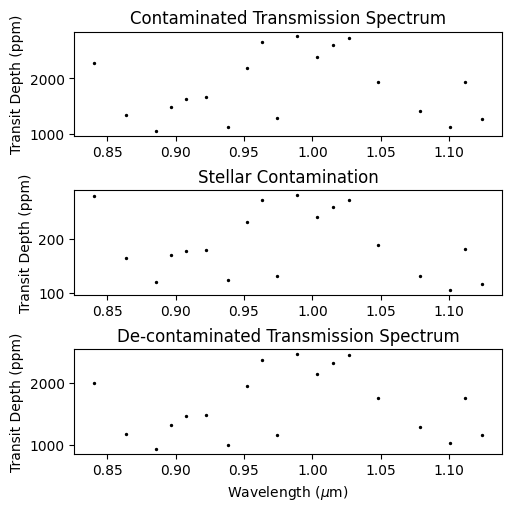

<Figure size 640x480 with 0 Axes>

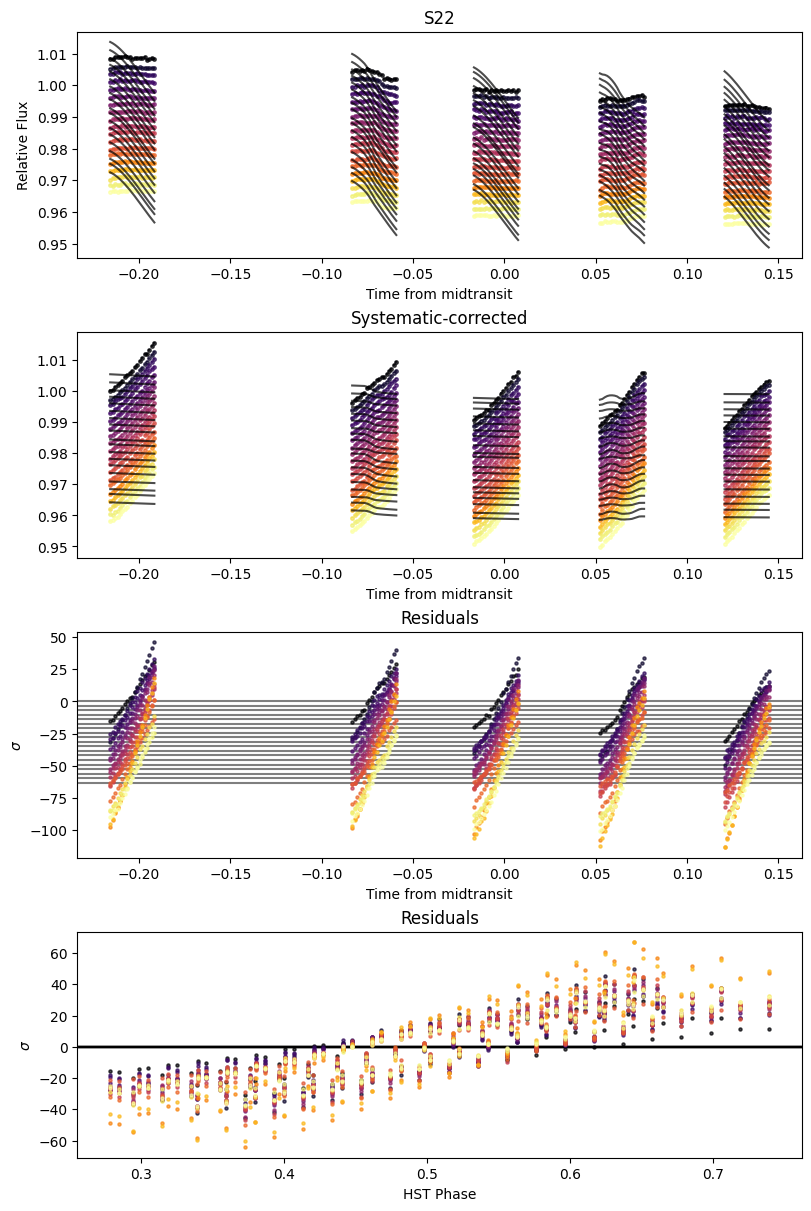

<Figure size 640x480 with 0 Axes>

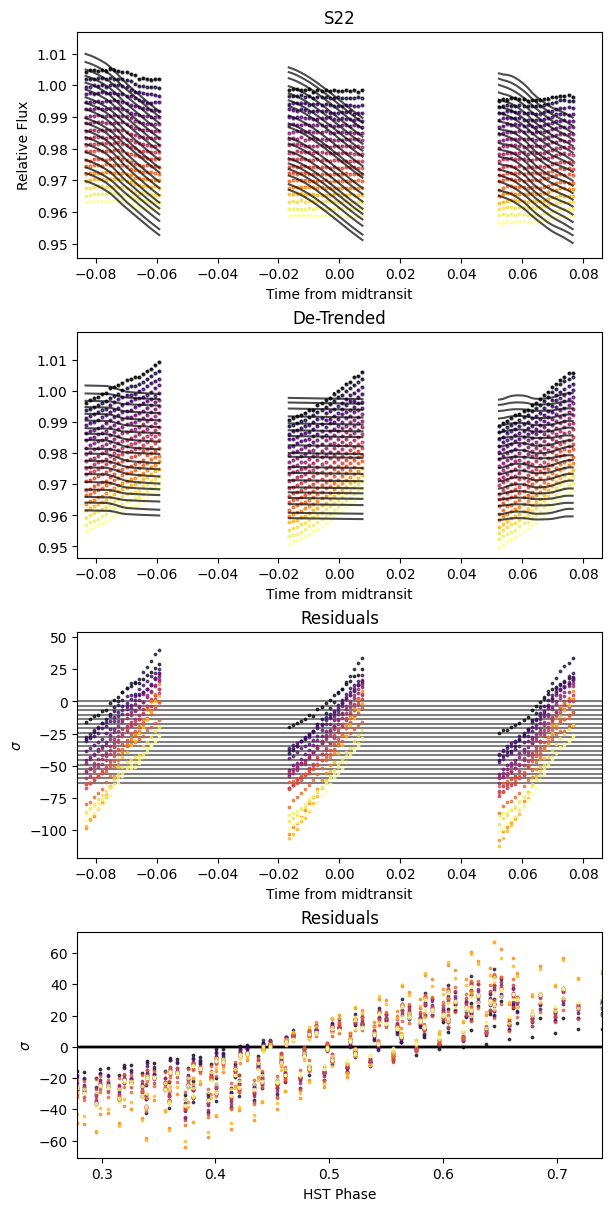

This Models Reduced Chisq = 565.470 for 79 parameters and 1805 data points


<Figure size 640x480 with 0 Axes>

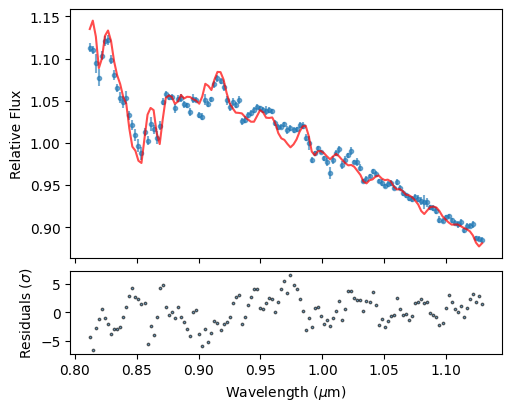

This Models Reduced Chisq = 6.899 for 5 parameters and 130 data points
Max Log Likelihood = 2699852.7


2699852.7123757713

<Figure size 640x480 with 0 Axes>

In [13]:
'Things that automatically get re-defined for either visit'
priors = _priors
params_config = _params_config
predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
binwidth = visits[f'{visit}']['native resolution']
exptime = visits[f'{visit}']['exp (s)']
grism = visits[f'{visit}']['Grism']
rainbow = read_rainbow(f"../data/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
speclc_rainbow = rainbow
for i in range(len(rainbow.wavelength.value)):
    'ADD CORRECTION TO UNCERTAINTIES'
    speclc_rainbow.uncertainty[i,:] = rainbow.uncertainty[i,:] * SED_err_factor[i]
binned_rainbow = speclc_rainbow.bin(wavelength_edges=speclc_bin_edges)
data_wavelengths = binned_rainbow.wavelength.value
img_date = binned_rainbow.time.value
data_flux = binned_rainbow.flux.value
relative_err = binned_rainbow.uncertainty.value/data_flux
time_from_T0 = img_date - predicted_T0
for i in range(len(data_wavelengths)):
    print(f'Median relative photon uncertainty at {data_wavelengths[i]:.4f} micron = {int(np.nanmedian(relative_err[i,:])*1e6)}ppm')
'remove the transit'
out_of_transit = ( speclc_rainbow.trim().mask_transit(period=8.463*u.day, t0=predicted_T0*u.day, duration=0.15*u.day) )
'define the appropriate arrays'
_meanOOTspec = out_of_transit.get_average_spectrum_as_rainbow()
meanOOTspec = _meanOOTspec.flux
meanOOTspec_relative_err = _meanOOTspec.uncertainty.value/meanOOTspec.value
oot_spec_err = (SED_err_kluge * meanOOTspec_relative_err).flatten()
SED_wavelengths = (_meanOOTspec.wavelength.value).flatten()
e_per_s = meanOOTspec / exptime
e_per_s_per_angstrom = e_per_s / binwidth
_w, _s, _e = read_sensitivity_curve(grism=grism)
binned_filter_response = bintogrid(_w.value, _s.value, newx=SED_wavelengths)['y'] * u.cm**2 / u.erg
_calibrated_mean_spec = e_per_s_per_angstrom.flatten() / binned_filter_response
calibrated_mean_spec = _calibrated_mean_spec.value/np.nanmean(_calibrated_mean_spec.value)
oot_spec_err = oot_spec_err * calibrated_mean_spec

# Label the orbits
orbit = np.zeros_like(img_date)
for j in range(len(img_date)):
    if j >= 1:
        if (img_date[j] - img_date[j - 1]) > 0.01:
            orbit[j] = (orbit[j - 1] + 1)
        else:
            orbit[j] = orbit[j - 1]

# Trim the first point from each orbit
ref_time = []
for o in np.unique(orbit):
    first_index = np.where(orbit == o)[0][0]
    ref_time.append(img_date[first_index])
    data_flux[:, first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
    relative_err[:, first_index] = np.nan
    img_date[first_index] = np.nan
    time_from_T0[first_index] = np.nan

# Set data to nan if it was in the pre-defined list of orbits to exclude
for orbit_to_exclude in orbits_to_exclude:
    data_flux[:, orbit == orbit_to_exclude] = np.nan
    relative_err[:, orbit == orbit_to_exclude] = np.nan
    img_date[orbit == orbit_to_exclude] = np.nan
    time_from_T0[orbit == orbit_to_exclude] = np.nan

# Populate ramp_phase time arrays
phase_list=[]
for o in [0,1,2,3,4,5,6,7]:
    rphase = (img_date[orbit==o] - ref_time[o]) / default_params['HST_period']
    phase_list.append(rphase)
ramp_phase = np.concatenate(phase_list)
breathing_phase = ( (img_date-ref_time[0]+0.02) / default_params['HST_period'] ) % 1

'Add wavelength-dependent u1 and u2 parameters'
for i in range(1,len(speclc_bin_edges)):
    params_config[f"u1_w{i}"] = (0.2, 0.3)
    params_config[f"u2_w{i}"] = (0.3, 0.4)
    priors[f"u1_w{i}"] = (0.08, 0.7)
    priors[f"u2_w{i}"] = (0.08, 0.7)

'Add wavelength-dependent rp/rs parameters'
for i in range(1,len(speclc_bin_edges)):
    params_config[f"rp_rs_w{i}"] = (0.03, 0.05)
    priors[f"rp_rs_w{i}"] = (0.01, 0.07)

planet_parameters = dict(
    inclination = np.radians(default_params['planet_i']),
    a = default_params['a_rstar'],
    rp = default_params['R0'],
    period = default_params['P_orb'],
    t0 = default_params['t0'],
    # omega = np.radians(default_params['omega']),
    ecc = 0.0,
    u1 = 0.2,
    u2 = 0.3,)

# Call the spectra based on temp
Cool_occulted, Cool_unocculted, Phot = [
    get_BTSettl_spectrum(T=Temp, grid = speclc_grid,w = speclc_bin_edges)
    for Temp in [default_params['T_occulted'],
             default_params['T_unocculted'],
             default_params['T_phot'] ] ]

active_star = ActiveStar(
    times = time_from_T0,
    inclination=jnp.radians(default_params['stellar_i']),
    T_eff=default_params['T_phot'],
    wavelength=Phot.wavelength.to_value(u.m), #use data wavelength array
    phot=Phot.flux.value, #This is the model spectrum for the photosphere temp
    P_rot=default_params['P_rot'])
for i in range(0, n_spots):
    lon = np.random.uniform(-2.8,2.8)
    lat = random.choice( [np.random.beta(2, 1)*(1.25 - 0.2) + 0.2, np.random.beta(1,2)*(3.0 - 2.0) + 2.0 ] )
    rad = 0.005

    latspot = dict(
        lon=lon,  # Longitude [rad]
        lat=lat,  # Latitude [rad]
        rad=rad,  # Radius [R_star]
        spectrum=Cool_unocculted.flux.value,
        temperature=default_params['T_unocculted'], )
    active_star.add_spot(**latspot)

# initial_lats = active_star.lat
# initial_lons = active_star.lon
# initial_radii = active_star.rad

n_dim = len(priors)
variable_names = list(params_config.keys())
p0 = initialize_walkers(n_walkers, params_config)

# 'Select a random set of parameters to test the initial models'
example_params = p0[np.random.randint(0, n_walkers - 1), :]
lnprob(example_params, plot=True,savefigs=False,samples=None)

In [14]:
'Set up MCMC'
label=f'{visit}_{model_designation}_{n_steps}steps_{int(len(speclc_bin_edges)-1)}bins_mcmc'
samples_fname = f"../data/samples/{label}.h5"
backend = emcee.backends.HDFBackend(samples_fname)
backend.reset(n_walkers, n_dim)        

'Run the MCMC'
print(f'Running MCMC sampler for {visit}')
sampler = emcee.EnsembleSampler(n_walkers,
                                n_dim, 
                                lnprob,
                                backend=backend)
result = sampler.run_mcmc(p0, n_steps, store=True, progress=True)

samples = sampler.chain[:, n_burnin:, :].reshape((-1, n_dim)).T

Running MCMC sampler for S22


Traceback (most recent call last):3<59:51:09, 131.87s/it]  
  File "/opt/anaconda3/envs/fleckopy/lib/python3.12/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/vq/zxq380ws52q37mjjtbt9c7rh0000gp/T/ipykernel_69113/826771163.py", line 21, in lnprob
    ln_like += lnlike_specLC(parameters,
               ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/vq/zxq380ws52q37mjjtbt9c7rh0000gp/T/ipykernel_69113/3281560147.py", line 57, in lnlike_specLC
    lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)
                                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt
 18%|█▊        | 366/2000 [19:45:34<88:12:58, 194.36s/it]

emcee: Exception while calling your likelihood function:
  params: [ 1.41281981e+01 -6.81235742e+00 -2.78233328e-04  1.21467256e-02
 -2.69988811e-02  1.62838814e-02  3.50013481e-03  1.84744681e+01
  2.49917020e-04  1.99824720e-01  1.83220422e-01  3.09314721e+03
  3.34203776e+03  3.94370885e+03 -1.67206344e+00 -1.29687635e+00
  1.09560853e+00  3.07134687e-01  9.07078031e-01  1.82868422e+00
  5.34650991e-02  5.66518735e-02  1.52678593e+00  2.64015871e-01
  2.31660331e-01  3.42157907e-01  2.24113165e-01  3.95478722e-01
  2.26365643e-01  3.85022230e-01  2.46176451e-01  3.45701925e-01
  2.16198352e-01  3.33803354e-01  2.39442094e-01  3.60126444e-01
  2.39737220e-01  3.31718334e-01  2.45216265e-01  3.76955327e-01
  2.41764439e-01  3.26731747e-01  2.76933187e-01  3.49133168e-01
  2.65547056e-01  3.33324048e-01  2.09250374e-01  3.44374523e-01
  2.61274159e-01  3.87486029e-01  2.72888908e-01  3.42030267e-01
  2.77510765e-01  3.87416313e-01  2.43835856e-01  3.49676985e-01
  2.55596703e-01  3.318

KeyboardInterrupt: 

In [ ]:
# samples = get_mcmc_samples(visit, model_designation, n_steps, int(len(speclc_bin_edges)-1), n_burnin,n_dim)

# if samples is not None:
#     print(f"Retrieved samples with shape: {samples.shape}")

In [ ]:
'Check for convergence (all should be > 100)'
for i in range(len(samples)):
    tau_f = emcee.autocorr.integrated_time(samples[i])
    print('(Nsteps-burnin)*nwalkers/tau=',int((n_steps-n_burnin)*n_walkers/tau_f))

'Return the most likely set of parameters'
flat_log_prob = sampler.get_log_prob(discard=n_burnin, flat=True)
best_index = np.argmax(flat_log_prob)  # Index of the highest log-probability
highest_prob_params = samples[:, best_index]
print("Highest Likelihood Parameters:")
for i,param in enumerate(highest_prob_params):
    print(f'{variable_names[i]}={param:.7f}')

'Extract and display best-fit parameters and uncertainties'
median_params = []
err_upper = []
err_lower = []
for i, param_samples in enumerate(samples):
    sig_1_results = np.percentile(param_samples, [15.9, 50.0, 84.1])
    median_params.append(sig_1_results[1])
    err_upper.append(sig_1_results[2] - sig_1_results[1])
    err_lower.append(sig_1_results[1] - sig_1_results[0])
params_dict = {name: median_params[i] for i, name in enumerate(params_config.keys())}
for i, label in enumerate(variable_names):
    print(f"{label}: {median_params[i]:.6f} +{err_upper[i]:.6f} -{err_lower[i]:.7f}")

lnprob(highest_prob_params, plot=True, savefigs=True, samples=samples)

In [10]:
rp_rs_values = [0.04293,
0.044803,
0.044291,
0.042568,
0.042287,
0.044958,
0.045096,
0.042714,
0.043889,
0.042716,
0.045695,
0.044598,
0.043049,
0.041068,
0.04496,
0.044541,
0.042564,
0.043099,
0.042502]

upper_uncertainties = np.abs([+0.000533,
+0.000791,
+0.001003,
+0.000587,
+0.000578,
+0.001153,
+0.000528,
+0.000700,
+0.000506,
+0.000474,
+0.000648,
+0.000912,
+0.000456,
+0.000533,
+0.000593,
+0.000876,
+0.000693,
+0.000505,
+0.000749])

lower_uncertainties = np.abs([-0.00058,
-0.0008577,
-0.0009321,
-0.0006246,
-0.0005754,
-0.0008383,
-0.0004779,
-0.0007537,
-0.0005393,
-0.0004735,
-0.0007226,
-0.0010428,
-0.0004837,
-0.0006202,
-0.0010188,
-0.0009424,
-0.0007971,
-0.0006101,
-0.0007976])

In [ ]:
# Create the table
spectra_table = Table()
# Add columns
spectra_table['wavelength_bin_center'] = data_wavelengths  # in microns
spectra_table['wavelength_bin_low'] = speclc_bin_edges[:-1]  # lower edge
spectra_table['wavelength_bin_high'] = speclc_bin_edges[1:]  # upper edge
spectra_table['rp_rs'] = rp_rs_values
spectra_table['rp_rs_upper_err'] = upper_uncertainties
spectra_table['rp_rs_lower_err'] = lower_uncertainties

# Save to FITS file
spectra_table.write(f'{grism}_{model_designation}_transmission_spectrum.fits', overwrite=True)

# Load the table from FITS file
table = Table.read(f'{grism}_{model_designation}_transmission_spectrum.fits')

wavelength_center = np.array(table['wavelength_bin_center'])
blue_edge = np.array(table['wavelength_bin_low'])
red_edge = np.array(table['wavelength_bin_high'])
rp_rs = np.array(table['rp_rs'])
upper_err = np.array(table['rp_rs_upper_err'])
lower_err = np.array(table['rp_rs_lower_err'])

print("Wavelength:", wavelength_center)
print("Rp/Rs:", rp_rs)
print("Upper errors:", upper_err)
print("Lower errors:", lower_err)

'Transmission Spectrum Plot'
norm = (data_wavelengths - data_wavelengths.min()) / np.ptp(data_wavelengths)
colors = [plt.cm.autumn(val) for val in norm]  # List of RGBA tuples
hex_colors = [matplotlib.colors.to_hex(color) for color in colors]  # Convert to hex strings
fig,ax = plt.subplots(1,1,figsize=(6,4),sharex=True)

ax.errorbar(data_wavelengths,np.array(rp_rs_values)**2, xerr=[wavelength_center-blue_edge,red_edge-wavelength_center],
            yerr=[np.array(upper_uncertainties/rp_rs_values) * np.array(rp_rs_values)**2, np.array(lower_uncertainties/rp_rs_values) * np.array(rp_rs_values)**2],fmt='o',
            ms=7,
            # markerfacecolor=colors,
            # cmap=plt.cm.autumn,
            # c=(data_wavelengths - data_wavelengths.min()) / np.ptp(data_wavelengths),  # Normalized values [0,1]
            # cmap='autumn',  # Use a colormap
            alpha=0.7)
ax.set_ylabel('Transit Depth')
ax.set_xlabel(r'Wavelength ($\mu$m)')

plt.savefig(f'../figs/{visit}_{model_designation}_transmissionspectrum.png',dpi=300)
plt.show()
plt.clf()

In [ ]:
'''##########
PLOTS TO MAKE
'''



'Plot contamination with sampled parameters'
fig,axs = plt.subplots(1,1,figsize=(6,4),sharex=True)

plt.savefig(f'../figs/{visit}_{model_designation}_contamination.png',dpi=300)
plt.show()
plt.clf()
'Plot each spec LC with randomly sampled parameters ad residuals (separate columns)'
fig,axs = plt.subplots(1,2,figsize=(8,4))
axs[0].set_ylabel()
axs[1].set_ylabel(r'$\sigma$')
axs[1].set_xlabel(r'Wavelength ($\mu$m)')
    axs[0].errorbar()
    axs[1].errorbar(wavelength, residual)
    plt.savefig(f'../figs/{visit}_{model_designation}_lc{i}.png',dpi=300)
    plt.show()
    plt.clf()

In [ ]:
# 'Make corner plot'
# rng = 0.9995
# fig = corner.corner( 
#     samples.T,show_titles=True, labels=variable_names,
#     range=[rng]*n_dim,smooth=1,quantiles=(0.16, 0.5, 0.84),
#     fill_contours=True, plot_datapoints=False,title_kwargs={"fontsize": 15},title_fmt='.4f',
#     hist_kwargs={"linewidth": 2.5},levels=[(1-np.exp(-0.5)),(1-np.exp(-2)),(1-np.exp(-4.5))])
# plt.suptitle(f"{visit} MCMC Results")
# plt.savefig(f'../figs/{visit}_{n_spots}spots_{n_steps}nsteps_corner.pdf')
# plt.clf()

In [ ]:
# Calculate figure dimensions
n_rows = len(wavelengths)
n_cols = 2

# Set dimensions per subplot (inches)
subplot_width = 4
subplot_height = 1.5

# Calculate total figure size
fig_width = n_cols * subplot_width
fig_height = n_rows * subplot_height

# Create figure with appropriate size
fig, axes = plt.subplots(n_rows, n_cols, 
                         figsize=(fig_width, fig_height),
                         squeeze=False)  # squeeze=False ensures axes is always 2D array

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.3, hspace=0.4)

# Plot your data - this is just an example
for row, wavelength in enumerate(wavelengths):
    for col in range(n_cols):
        ax = axes[row, col]
        
        # Plot your actual data here
        ax.plot(data[wavelength])
        ax.plot(wavelengths, residuals)
        # Add labels/titles as needed
        ax.set_title(f'Wavelength: {wavelength} micron')
        if col == 0:
            if 
            ax.set_xlabel('Time from T0 (days)')
            ax.set_ylabel('Relative Flux')

plt.tight_layout()
plt.show()

In [ ]:
'Make a gif of the stellar surface'

# Set up the 2-panel figure
fig,axes = plt.subplots(2,1,figsize=(6, 6), dpi=100)

starmap_ax = axes[0]
transit_ax = axes[1]

writer = PillowWriter(fps=50)

times = np.linspace(-0.2,0.2,1000)

'Update Stellar Parameters'
# active_star.times = times

lcmodel, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)
notrans_model, contam, X, Y, spectrum_at_transit = active_star.transit_model(**notrans_planet_parameters)
rotation_spectrum = active_star.rotation_spectrum()

with writer.saving(fig, 'spectral_contrasts.gif', dpi=100):

    for i,wl in enumerate(model_wavelengths):
        for ax in [transit_ax, starmap_ax]:
            ax.clear()
        
        'Lower Plot - Transit'
        lc_i = lcmodel.T[i]
        rotation_i = notrans_model.T[i]
        transit_ax.plot(times, lc_i/rotation_i,
                        color='k')
                        
        'Upper Plot - stellar surface'
        active_star.plot_star(
            t0=planet_parameters['t0'],
            rp=planet_parameters['rp'],  # Exoplanet radius in units of stellar radii
            a=planet_parameters['a'],  # Planetary semi-major axis in units of stellar radii
            inclination=planet_parameters['inclination'],  # Planetary orbital inclination [radians]
            ecc=planet_parameters['ecc'],
            wl_bin = i,
            ax=starmap_ax)
        starmap_ax.set_title(f'{model_wavelengths[i]:.2f}'+r'$\mu$m')

        transit_ax.set_title(r'Transit with rotation removed')
        transit_ax.set_xlabel('Time from Mid-Transit (d)')
        transit_ax.set_ylabel('Relative Flux')
        transit_ax.set_xlim(-0.2,0.2)
        transit_ax.set_ylim(0.9976,1.0001)

        plt.tight_layout()
        
        writer.grab_frame()

print("GIF created successfully!")

In [ ]:
# Set up the 2-panel figure
fig,axes = plt.subplots(2,1,figsize=(6, 6), dpi=100)

starmap_ax = axes[0]
transit_ax = axes[1]

writer = PillowWriter(fps=15)

times = np.linspace(-0.2,0.2,150)

'Update Stellar Parameters'
active_star.times = times

lcmodel, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)

with writer.saving(fig, 'rotatingspectransits.gif', dpi=100):

    for i,time in enumerate(times):
        for ax in [transit_ax, starmap_ax]:
            ax.clear()
        
        'Lower Plot - Transit'
        for j, lc_j in enumerate(lcmodel.T):
            jitter = np.random.normal(0,jitter_sigma[j],lc_j.shape)
            lc_j = lc_j + jitter
            transit_ax.errorbar(times[:i], lc_j[:i]/lc_j.mean()-0.0015*j, yerr = jitter_sigma[j], ms=0.5,
                            color=plt.cm.RdYlBu_r((model_wavelengths[j] - model_wavelengths.min()) / np.ptp(model_wavelengths)))
        
        'Upper Plot - stellar surface'
        active_star.plot_star(
            t0=time,
            rp=planet_parameters['rp'],  # Exoplanet radius in units of stellar radii
            a=planet_parameters['a'],  # Planetary semi-major axis in units of stellar radii
            inclination=planet_parameters['inclination'],  # Planetary orbital inclination [radians]
            ecc=planet_parameters['ecc'],
            wl_bin = 0,
            ax=starmap_ax)

        # Calculate the position of the moving circle (from -0.2 to 0.2)
        circle_x = np.interp(i, [0, len(times)-1], [-2.9, 2.78])
        # Add the moving black circle
        # atm_circle = plt.Circle((circle_x, -0.155), 0.052, color='skyblue')  # Adjust radius (0.01) as needed
        # starmap_ax.add_patch(atm_circle)
        circle = plt.Circle((circle_x, -0.155), 0.045, color='black')  # Adjust radius (0.01) as needed
        starmap_ax.add_patch(circle)

        starmap_ax.set_title('Stellar Surface')
        starmap_ax.set_facecolor('black')
        transit_ax.set_title(r'Spectroscopic Transits from 0.5-4.0 $\mu$m')
        transit_ax.set_xlabel('Time from Mid-Transit (d)')
        transit_ax.set_ylabel('Relative Flux')
        transit_ax.set_xlim(-0.175,0.175)
        transit_ax.set_ylim(0.969,1.01)

        plt.tight_layout()
        
        writer.grab_frame()

print("GIF created successfully!")

In [ ]:
# Set up the 2-panel figure
fig,axes = plt.subplots(3,1,figsize=(8, 8), dpi=150)

starmap_ax = axes[0]
# starspec_ax = axes[0,1]
transit_ax = axes[1]
contam_ax = axes[2]

starmap_ax.set_title('Stellar Surface')
# starspec_ax.set_title('Stellar Spectrum')
# starspec_ax.set_xlabel('Wavelength (micron)')
# starspec_ax.set_ylabel('Flux')
transit_ax.set_title('Spectroscopic Transits')
transit_ax.set_xlabel('Time from Mid-Transit (d)')
transit_ax.set_ylabel('Relative Flux')
transit_ax.set_ylim(0.98,1.01)
contam_ax.set_title('Contamination')
contam_ax.set_ylabel('Depth (ppm)')
contam_ax.set_xlabel('Wavelength (micron)')
starmap_ax.set_facecolor('black')

writer = PillowWriter(fps=20)

times = np.linspace(-0.2,0.2,100)
spot_sizes = np.linspace(0,0.05,100)

'Update Stellar Parameters'
active_star.times = times
active_star.phot = Phot
active_star.wavelength = jnp.array(model_wavelengths/1e4)
active_star.spectrum = jnp.array([Cool] * (n_spots+n_fixedspots))
# active_star.T_eff = default_params['T_phot']
# active_star.temperature = jnp.array([default_params["T_spot"]] * (n_spots+n_fixedspots))
active_star.rad = jnp.array([0.0] * (n_spots+n_fixedspots))
# active_star.lon = active_star.lon.at[-n_spots:].set([params.get(f"spot{i}_lon", default_params[f"spot{i}_lon"]) for i in range(1, n_spots + 1)][::-1])
# active_star.lat = active_star.lat.at[-n_spots:].set([params.get(f"spot{i}_lat", default_params[f"spot{i}_lat"]) for i in range(1, n_spots + 1)][::-1])
active_star.rad = active_star.rad.at[-n_spots:].set([default_params[f"spot{i}_rad"] for i in range(1, n_spots + 1)][::-1])

lcmodel, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)

# contam_breakdown_ax.plot(model_wavelengths, contam, color='k')

with writer.saving(fig, 'contam_animation_fspot.gif', dpi=150):

    for i,rspot in enumerate(spot_sizes):
        for ax in [transit_ax, starmap_ax, contam_ax]:
            ax.clear()

        starmap_ax.set_facecolor('black')

        transit_ax.set_xlim(-0.2,0.2)
        contam_ax.set_ylim(0.0035*1e6,0.0052*1e6)

        active_star.rad = jnp.array([rspot] * (n_spots+n_fixedspots))
        # active_star.lon = active_star.lon.at[-n_spots:].set([params.get(f"spot{i}_lon", default_params[f"spot{i}_lon"]) for i in range(1, n_spots + 1)][::-1])
        # active_star.lat = active_star.lat.at[-n_spots:].set([params.get(f"spot{i}_lat", default_params[f"spot{i}_lat"]) for i in range(1, n_spots + 1)][::-1])
        active_star.rad = active_star.rad.at[-n_spots:].set([default_params[f"spot{i}_rad"] for i in range(1, n_spots + 1)][::-1])
        
        lcmodel, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)

        'Lower Left Plot - Transit'
        for j, lc_j in enumerate(lcmodel.T): 
            transit_ax.plot(times, lc_j/lc_j.mean()+0.001*j,
                            color=plt.cm.turbo((model_wavelengths[j] - model_wavelengths.min()) / np.ptp(model_wavelengths)))

        'bottom plot - contam'
        contam_ax.plot(model_wavelengths, contam*1e6,
                       color='k')

        'Upper Left Plot - stellar surface'
        active_star.plot_star(
            t0=0,
            rp=planet_parameters['rp'],  # Exoplanet radius in units of stellar radii
            a=planet_parameters['a'],  # Planetary semi-major axis in units of stellar radii
            inclination=planet_parameters['inclination'],  # Planetary orbital inclination [radians]
            ecc=planet_parameters['ecc'], ax=starmap_ax)
                
        writer.grab_frame()

print("GIF created successfully!")